## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [3]:
years = range(2009, 2024)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2009 | (8844, 102)
Year: 2010 | (8844, 102)
Year: 2011 | (8844, 102)
Year: 2012 | (8844, 102)
Year: 2013 | (8844, 102)
Year: 2014 | (8844, 102)
Year: 2015 | (8844, 102)
Year: 2016 | (8844, 102)
Year: 2017 | (8844, 102)
Year: 2018 | (8844, 102)
Year: 2019 | (8844, 102)
Year: 2020 | (8844, 102)
Year: 2021 | (8844, 102)
Year: 2022 | (8844, 102)
Year: 2023 | (8844, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,478.611967,4.13,15.51,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,195.752531,0.31,14.83,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2009,3,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,130.550646,3.03,19.79,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.92536,36.22923,2,1,1,2009,4,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,137.493718,5.95,25.37,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN
4,0,2009-05,EL3,

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

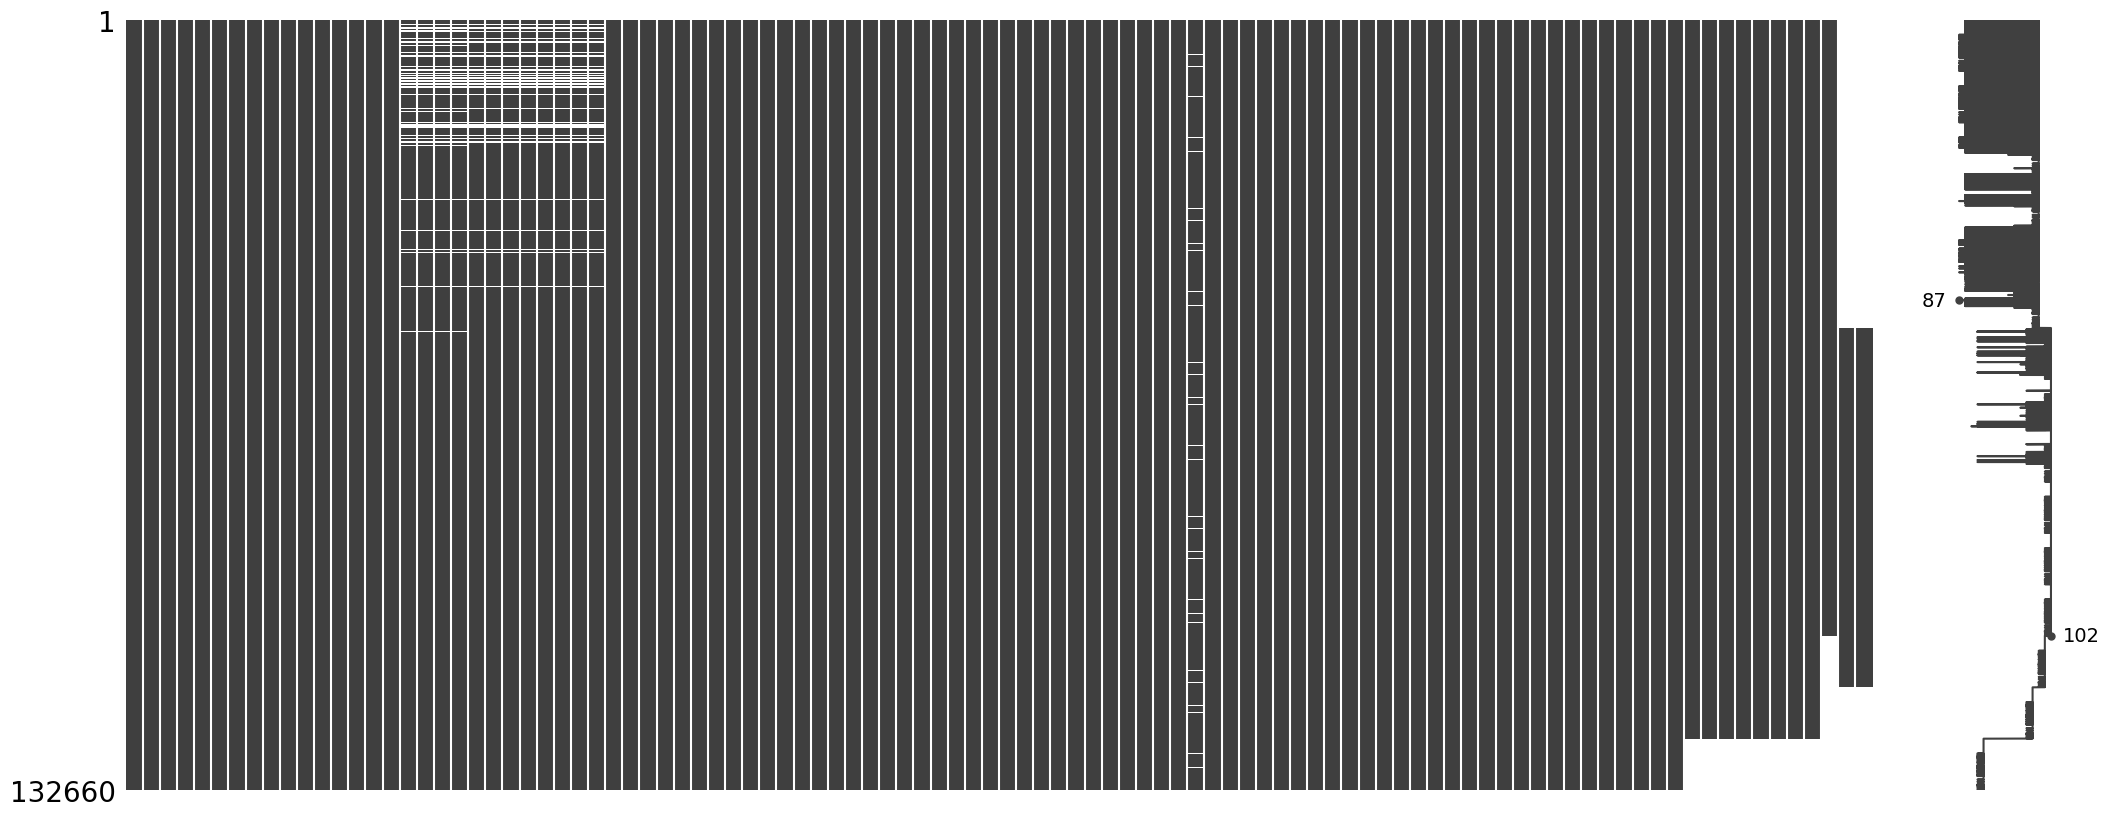

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,5.6196
17,ndmi,5.6196
18,ndwi,5.6196
19,ndbi,5.6196
20,ndvi_mean,4.9457
...,...,...
97,F_Y_GE65,6.6667
98,F_TOTAL,6.6667
99,MIO_EUR,20.0000
100,L_TOTAL,53.3333


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'rainfall_acc', 'NUTS1_ID']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2009-01,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,10.907419,10.546429,15.258387,19.500667,8.132581,8.132581,6.066429,7.096452,8.885333,9.520000,9.520000,8.306429,11.177419,14.193000,4.13,15.51,15.439096,86.815065,114.181245,478.611967,478.611967,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN,2,1,1
1,2009-02,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,2,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,10.907419,10.546429,15.258387,19.500667,6.066429,8.132581,6.066429,7.096452,8.885333,8.306429,9.520000,8.306429,11.177419,14.193000,0.31,14.83,6.991162,34.645614,66.767847,199.896512,674.364499,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN,2,1,1
2,2009-03,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,3,2009,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,10.907419,10.546429,15.258387,19.500667,7.096452,8.132581,6.066429,7.096452,8.885333,11.177419,9.520000,8.306429,11.177419,14.193000,3.03,19.79,4.211311,12.417633,25.670973,124.823961,804.915144,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN,2,1,1
3,2009-04,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,4,2009,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,10.907419,10.546429,15.258387,19.500667,8.885333,8.132581,6.066429,7.096452,8.885333,14.193000,9.520000,8.306429,11.177419,14.193000,5.95,25.37,4.583124,4.529084,13.596775,137.493718,942.408862,17.833333,18.666667,44.444444,779.082600,42.0,0.0,42.0,10.833333,27.333333,27.333333,8.833333,2212.0,478.0,6.0,92.933810,1102.0,35.0,35.0,1079.0,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.0,1.499166,22,83,20,83.0,20,83,9,9,4,2,2,2,0,38177.0,191548.0,41050.0,270775.0,36486.0,188403.0,54929.0,279818.0,13405.16,NaN,NaN,2,1,1
4,2009-05,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,0,22.92536,36.22923,5,2009,0.362634,0.048065,-0.332113,-0.048065,0.369133,0.061589,

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [19]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
70752,2017-01,"πειραιας, νησοι",0,22.92536,36.22923,1,2017,0.320983,-0.065077,-0.315225,0.065077,0.338934,-0.000577,-0.299791,0.000577,0.039617,0.063880,0.047819,0.063880,8.614516,8.614516,13.005714,16.47129,19.667333,5.713226,5.713226,4.836429,9.388065,10.612667,7.163871,7.163871,8.921071,12.929677,15.14,-1.61,14.31,9.868986,9.473027,148.672731,305.381857,305.938569,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,22,91,20,91.0,20,91,9,9,4,2,2,2,0,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
70753,2017-02,"πειραιας, νησοι",0,22.92536,36.22923,2,2017,0.307796,-0.027721,-0.295197,0.027721,0.331896,0.016421,-0.297595,-0.016421,0.036822,0.040848,0.030056,0.040848,13.005714,8.614516,13.005714,16.47129,19.667333,4.836429,5.713226,4.836429,9.388065,10.612667,8.921071,7.163871,8.921071,12.929677,15.14,-2.77,16.57,7.410268,8.991146,12.621684,208.860727,513.426073,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,22,91,20,91.0,20,91,9,9,4,2,2,2,0,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
70754,2017-03,"πειραιας, νησοι",0,22.92536,36.22923,3,2017,0.292843,0.004913,-0.268773,-0.004913,0.314003,0.037067,-0.276232,-0.037067,0.033647,0.029666,0.024206,0.029666,16.471290,8.614516,13.005714,16.47129,19.667333,9.388065,5.713226,4.836429,9.388065,10.612667,12.929677,7.163871,8.921071,12.929677,15.14,6.23,23.75,4.852546,34.387001,48.279032,150.395999,663.855010,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,22,91,20,91.0,20,91,9,9,4,2,2,2,0,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
70755,2017-04,"πειραιας, νησοι",0,22.92536,36.22923,4,2017,0.359477,-0.003222,-0.351171,0.003222,0.310577,0.030502,-0.296107,-0.030502,0.046585,0.022032,0.040980,0.022032,19.667333,8.614516,13.005714,16.47129,19.667333,10.612667,5.713226,4.836429,9.388065,10.612667,15.140000,7.163871,8.921071,12.929677,15.14,7.01,27.79,3.391857,1.240708,78.630782,101.755700,765.610710,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,22,91,20,91.0,20,91,9,9,4,2,2,2,0,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
70756,2017-05,"πειραιας, νησοι",0,22.92536,36.22923,5,2017,0.419994,0.030457,-0.399196,-0.030457,0.415120,0.057814,-0.386438,-0.057814,0.033572,0

In [20]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
70752,0,EL30,EL307,κυθηρων,2018,1,22.92536,36.22923,0.365836,0.118381,-0.299258,-0.118381,0.225004,0.089114,-0.157882,-0.089114,0.063362,0.051224,0.059956,0.051224,15.270645,12.314516,13.587143,15.691935,22.854667,8.366774,7.175806,7.766429,9.799677,12.676667,11.818710,9.745161,10.676786,12.745806,17.765667,3.15,17.25,5.362439,115.718359,150.551843,164.818729,814.180885,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
71489,0,EL30,EL307,κυθηρων,2018,2,22.92536,36.22923,0.433760,0.088725,-0.389702,-0.088725,0.382032,0.087819,-0.327709,-0.087819,0.087054,0.089395,0.064463,0.089395,12.314516,12.314516,13.587143,15.691935,22.854667,7.175806,7.175806,7.766429,9.799677,12.676667,9.745161,9.745161,10.676786,12.745806,17.765667,-1.37,15.45,26.263900,0.184734,20.501405,814.120885,1375.932909,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
72226,0,EL30,EL307,κυθηρων,2018,3,22.92536,36.22923,0.125548,0.492821,-0.127835,-0.492821,0.111530,0.495541,-0.112766,-0.495541,0.026187,0.030717,0.016460,0.030717,13.587143,12.314516,13.587143,15.691935,22.854667,7.766429,7.175806,7.766429,9.799677,12.676667,10.676786,9.745161,10.676786,12.745806,17.765667,3.79,15.73,20.062572,187.811342,437.855954,561.752024,1432.469709,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
72963,0,EL30,EL307,κυθηρων,2018,4,22.92536,36.22923,-0.022169,0.682699,-0.001832,-0.682699,0.202587,0.301791,-0.190950,-0.301791,0.050323,0.034742,0.031024,0.034742,15.691935,12.314516,13.587143,15.691935,22.854667,9.799677,7.175806,7.766429,9.799677,12.676667,12.745806,9.745161,10.676786,12.745806,17.765667,6.35,20.83,1.823768,10.109603,26.116745,56.282742,1485.366167,18.25,19.166667,43.560606,818.674094,42.0,-2.0,44.0,10.166667,28.333333,28.333333,7.833333,2303.0,962.0,4.0,133.910901,1433.0,64.0,64.0,678.0,22,20,20,9,9,4,2,2,1554.806149,2545.316809,27,217.50255,313.370524,207.335062,0.0,1.499166,36268.0,159775.0,44996.0,241039.0,33995.0,170880.0,59940.0,264815.0,9536.53,23572.0,23617.0,2,1,1
73700,0,EL30,EL307,κυθηρων,2018,5,22.92536,36.22923,0.443291,0.090085,-0.423602,-0.090085,0.406997,0.083427,-0.390538,-0.083427,0.055358,0.047092,0.026341,0.047092,22.854667,12.314516,13.587143,15.691935,22.854667,12

<Axes: >

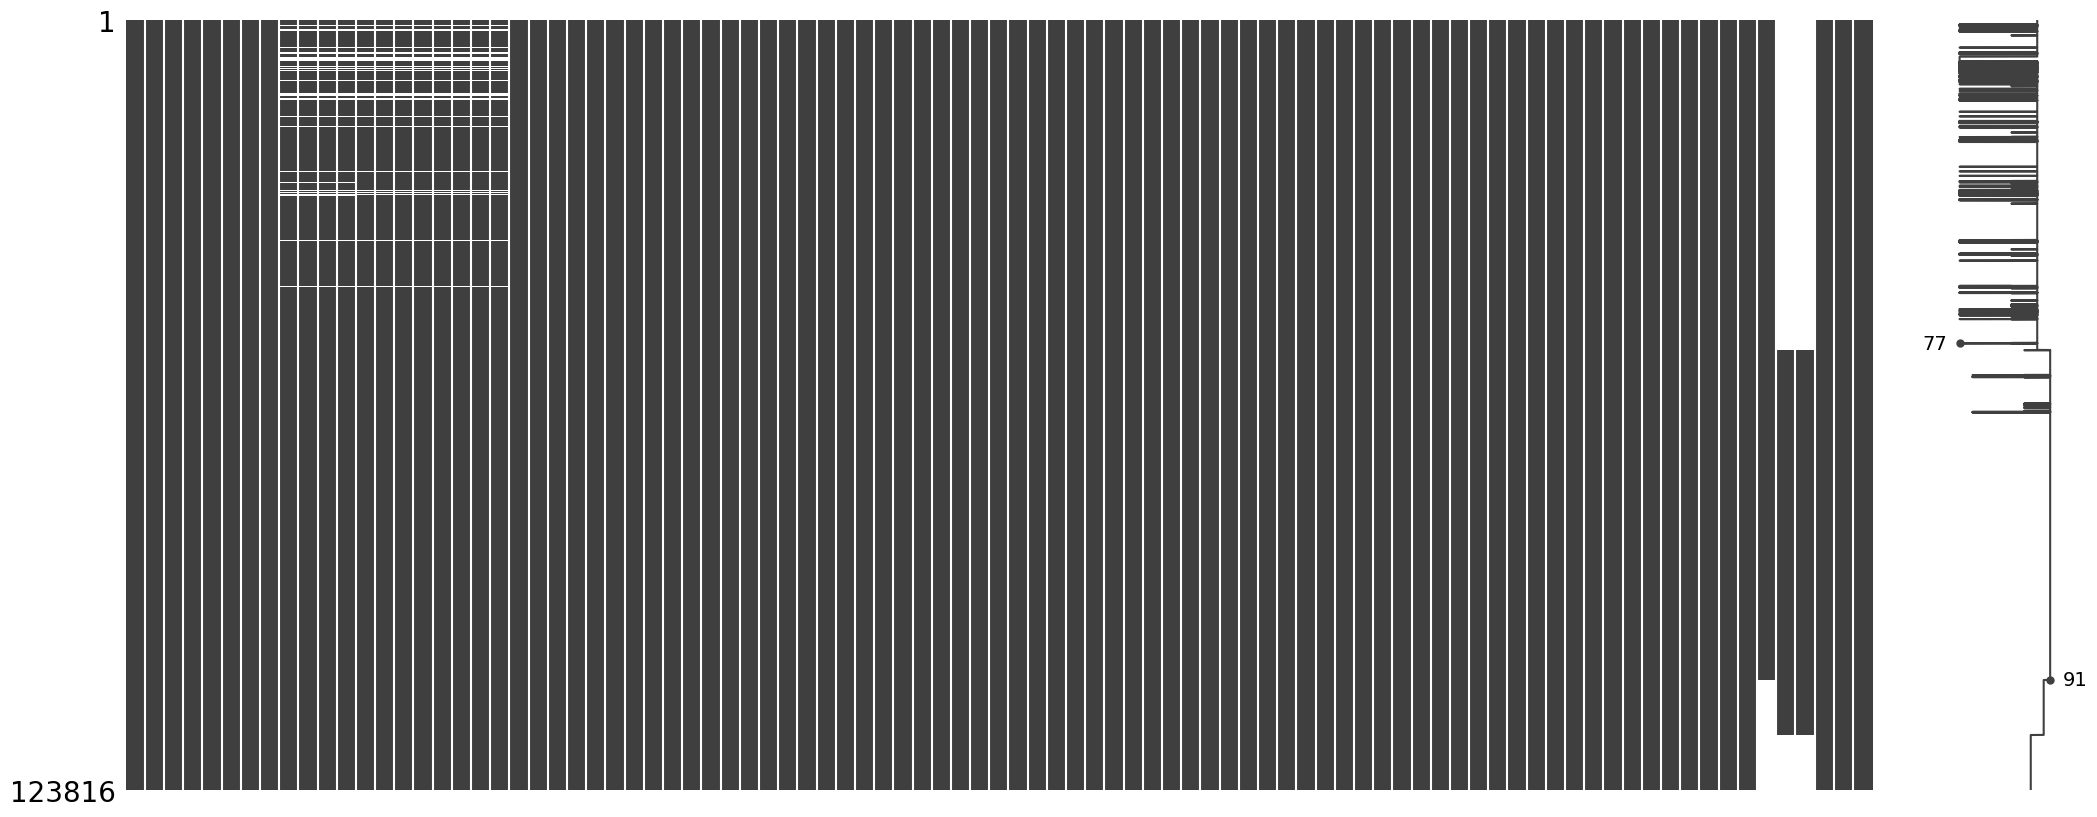

In [21]:
missingno.matrix(dataset_operational)

In [22]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,3.9728
9,ndmi,3.9728
10,ndwi,3.9728
11,ndbi,3.9728
12,ndvi_mean,3.3558
13,ndmi_mean,3.3558
14,ndwi_mean,3.3558
15,ndbi_mean,3.3558
16,ndvi_std,3.3558
17,ndmi_std,3.3558


In [23]:
# dataset_monthly.cases.sum()

In [24]:
# dataset_operational.cases.sum()

In [25]:
years = dataset_operational.year.unique().tolist()

In [26]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)